In [1]:
"""
01_generate_phantom.py
----------------------
Génère un phantom abdominal 3D synthétique avec bruit speckle réaliste.
Un phantom est un objet simulé utilisé pour valider les algorithmes
d'imagerie sans données patient réelles.
"""
import os
import numpy as np
from scipy.ndimage import gaussian_filter

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)


def generate_speckle_noise(shape, mean=1.0, sigma=0.15):
    real = np.random.normal(0, sigma, shape)
    imag = np.random.normal(0, sigma, shape)
    speckle = np.sqrt(real**2 + imag**2)
    return speckle / speckle.mean() * mean


def generate_phantom_3d(size=128, seed=None):
    if seed is not None:
        np.random.seed(seed)

    vol = np.zeros((size, size, size), dtype=np.float32)
    x = np.linspace(-1, 1, size)
    y = np.linspace(-1, 1, size)
    z = np.linspace(-1, 1, size)
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

    wall_mask = (Z > 0.7) & (Z < 0.85)
    vol[wall_mask] = 0.6

    liver_mask = ((X/0.7)**2 + (Y/0.6)**2 + ((Z-0.1)/0.5)**2) < 1.0
    liver_mask &= (Z < 0.7)
    vol[liver_mask] = 0.45

    vessel_mask = ((X - 0.2)**2 + (Y + 0.1)**2 < 0.08**2) & (Z > -0.3) & (Z < 0.4)
    vol[vessel_mask] = 0.15

    lesion_mask = ((X + 0.25)**2 + (Y - 0.15)**2 + (Z + 0.1)**2) < 0.12**2
    vol[lesion_mask] = 0.75

    noise_texture = gaussian_filter(np.random.randn(size, size, size), sigma=2)
    vol[liver_mask] += noise_texture[liver_mask] * 0.05

    speckle = generate_speckle_noise(vol.shape, mean=1.0, sigma=0.2)
    vol = vol * speckle
    vol = (vol - vol.min()) / (vol.max() - vol.min() + 1e-8)

    # NOTE: vessel_mask est defini comme sous-ensemble geometrique de liver_mask
    # dans les donnees (le cylindre est bien a l'interieur de l'ellipsoide),
    # on le garde independant pour l'evaluation.
    gt_masks = {
        "wall": wall_mask,
        "liver": liver_mask,
        "vessel": vessel_mask,
        "lesion": lesion_mask,
    }
    return vol, gt_masks


if __name__ == "__main__":
    print("Generating 3D ultrasound phantom...")
    phantom, gt_masks = generate_phantom_3d(size=128, seed=42)

    np.save(f"{DATA_DIR}/phantom_us_3d.npy", phantom)
    for name, mask in gt_masks.items():
        np.save(f"{DATA_DIR}/gt_{name}_mask.npy", mask)

    print(f"Saved: {DATA_DIR}/phantom_us_3d.npy")
    print(f"  Shape: {phantom.shape}")
    print(f"  Range: [{phantom.min():.3f}, {phantom.max():.3f}]")
    print("Saved ground-truth masks: wall, liver, vessel, lesion")

Generating 3D ultrasound phantom...
Saved: data/phantom_us_3d.npy
  Shape: (128, 128, 128)
  Range: [0.000, 1.000]
Saved ground-truth masks: wall, liver, vessel, lesion


Loading phantom + ground-truth masks...
Denoising (median filter 3D)...
Enhancing for DISPLAY only (CLAHE)...
Segmenting structures (Otsu multi-niveaux sur volume debruite)...
  Seuils Otsu calibres automatiquement: [np.float64(0.122), np.float64(0.171), np.float64(0.217)]
  Dice foie   : 0.994
  Dice lesion : 0.869
  Dice vaisseau: 0.863
Segmentation masks saved.
Saved: results/02_preprocessing_pipeline.png


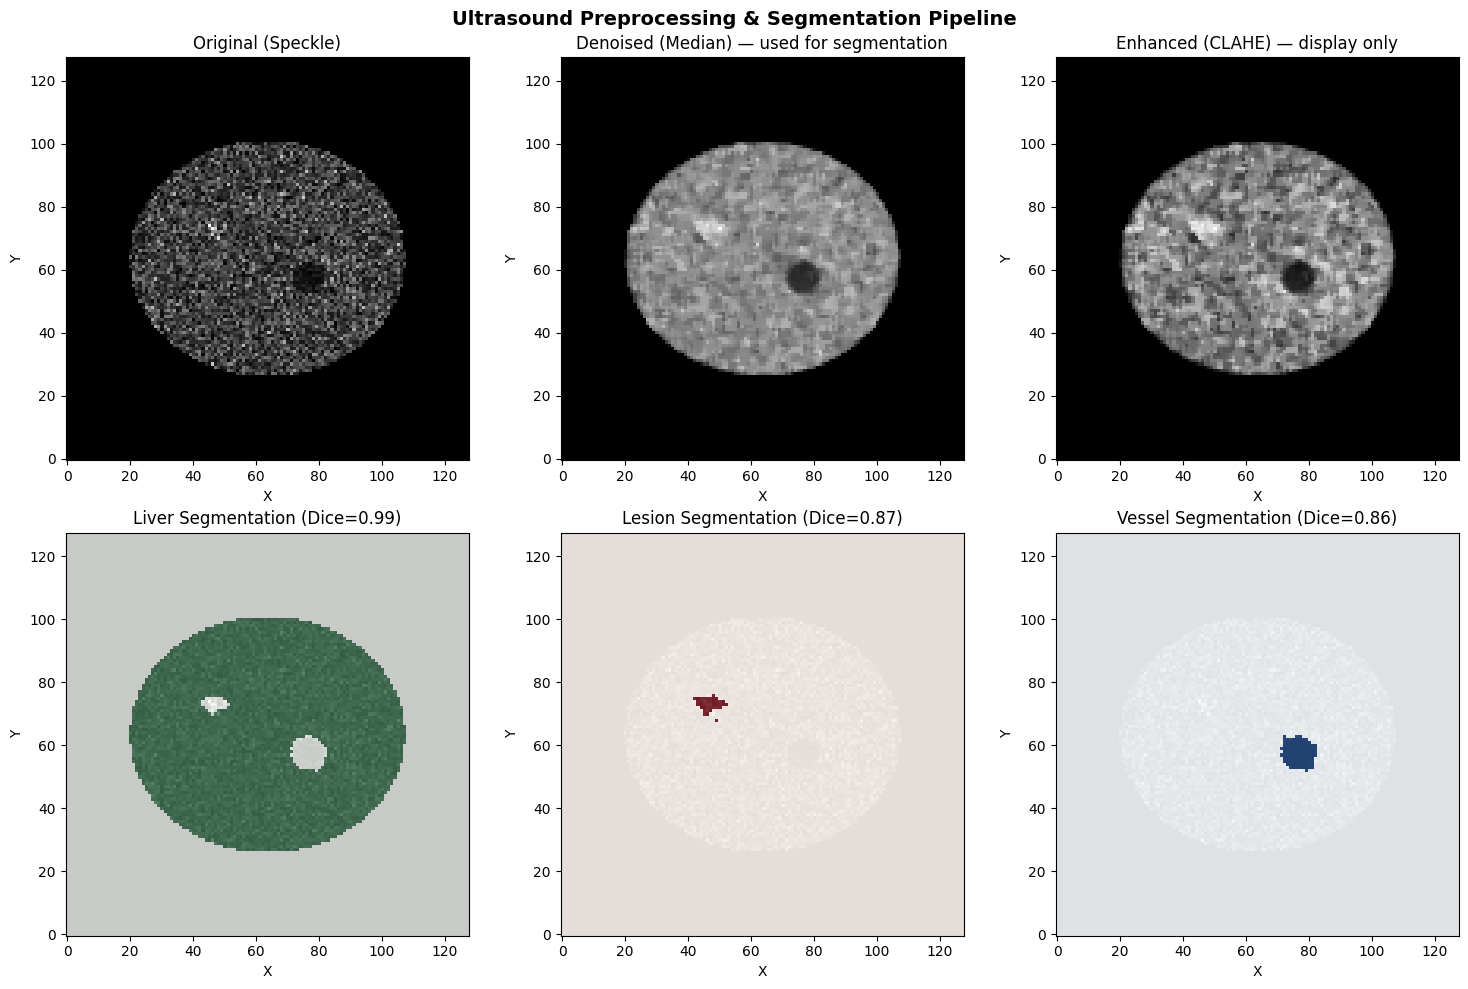

In [2]:
"""
02_preprocess_segment.py
------------------------
Pipeline de prétraitement d'image échographique:
  - Réduction du speckle (filtre médian)
  - Amélioration du contraste (CLAHE)
  - Segmentation des structures d'intérêt
"""
import os
import numpy as np
import cv2
from scipy import ndimage
from skimage.filters import threshold_multiotsu
import matplotlib.pyplot as plt

DATA_DIR = "data"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)


def apply_clahe_3d(volume):
    """CLAHE slice-par-slice -- utilise UNIQUEMENT pour l'affichage."""
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = np.zeros_like(volume)
    for i in range(volume.shape[2]):
        slice_2d = (volume[:, :, i] * 255).astype(np.uint8)
        enhanced[:, :, i] = clahe.apply(slice_2d) / 255.0
    return enhanced


def largest_component(mask, min_size=1):
    """Garde uniquement la plus grande composante connexe (retire le bruit poivre-et-sel)."""
    labeled, n = ndimage.label(mask)
    if n == 0:
        return mask
    sizes = ndimage.sum(mask, labeled, range(1, n + 1))
    if sizes.max() < min_size:
        return np.zeros_like(mask)
    biggest = np.argmax(sizes) + 1
    return labeled == biggest


def largest_compact_component(mask, min_size=1, max_aspect=3.0):
    """
    Comme largest_component, mais rejette les composantes "en nappe fine"
    (ex: la paroi abdominale) en comparant les dimensions de leur bounding
    box. Une lesion est ~spherique (aspect proche de 1) ; une nappe fine
    a un aspect tres eleve (une dimension beaucoup plus petite que les
    deux autres). Retombe sur largest_component si aucune composante
    compacte n'est trouvee.
    """
    labeled, n = ndimage.label(mask)
    if n == 0:
        return mask
    objs = ndimage.find_objects(labeled)
    best_label, best_size = None, 0
    for i, sl in enumerate(objs, start=1):
        if sl is None:
            continue
        size = (labeled[sl] == i).sum()
        if size < min_size:
            continue
        dims = [sl[a].stop - sl[a].start for a in range(3)]
        aspect = max(dims) / max(1, min(dims))
        if aspect <= max_aspect and size > best_size:
            best_label, best_size = i, size
    if best_label is None:
        return largest_component(mask, min_size=min_size)
    return labeled == best_label


def filter_by_size(mask, min_size):
    """Retire toutes les composantes connexes plus petites que min_size (nettoyage du bruit)."""
    labeled, n = ndimage.label(mask)
    if n == 0:
        return mask
    sizes = ndimage.sum(mask, labeled, range(1, n + 1))
    keep = np.zeros_like(mask)
    for i, s in enumerate(sizes, start=1):
        if s >= min_size:
            keep |= (labeled == i)
    return keep


def segment_structures(denoised_vol):
    """
    Segmentation par seuillage Otsu multi-niveaux + nettoyage morphologique,
    calibree sur le volume DEBRUITE (pas CLAHE).
    """
    fg_values = denoised_vol[denoised_vol > 0.01]
    # 4 classes sur le foreground: vaisseau (bas) / foie / paroi-lesion (haut)
    t1, t2, t3 = threshold_multiotsu(fg_values, classes=4)

    body = denoised_vol > 0.01
    body_filled = ndimage.binary_fill_holes(body)          # interieur "plein" du torse
    body_filled = largest_component(body_filled)             # retire les artefacts isoles

    # Vaisseau: valeur basse, a l'interieur du corps (pas le fond), on garde
    # la plus grande composante connexe (le vaisseau est le seul objet sombre
    # de cette taille -- le reste n'est que du bruit speckle residuel)
    vessel_candidate = (denoised_vol > 0.01) & (denoised_vol <= t1) & body_filled
    vessel = largest_component(vessel_candidate, min_size=150)
    vessel = ndimage.binary_closing(vessel, iterations=1)

    # Lesion: valeur haute + forme compacte (spherique), pas une nappe fine
    # (la paroi abdominale depasse aussi ce seuil par endroits, mais elle est
    # plate: on l'elimine avec le filtre d'aspect-ratio)
    lesion_candidate = denoised_vol > t3
    lesion = largest_compact_component(lesion_candidate, min_size=80, max_aspect=3.0)
    lesion = ndimage.binary_closing(lesion, iterations=1)

    # Foie: tout le tissu "plein" du corps, hors vaisseau et hors lesion
    liver = body_filled & ~vessel & ~lesion
    liver = ndimage.binary_closing(liver, iterations=1)

    return liver, lesion, vessel, (t1, t2, t3)


def dice(a, b):
    a = a.astype(bool)
    b = b.astype(bool)
    inter = np.logical_and(a, b).sum()
    denom = a.sum() + b.sum()
    return 2 * inter / denom if denom > 0 else 1.0


if __name__ == "__main__":
    print("Loading phantom + ground-truth masks...")
    phantom = np.load(f"{DATA_DIR}/phantom_us_3d.npy")
    gt_liver = np.load(f"{DATA_DIR}/gt_liver_mask.npy")
    gt_vessel = np.load(f"{DATA_DIR}/gt_vessel_mask.npy")
    gt_lesion = np.load(f"{DATA_DIR}/gt_lesion_mask.npy")
    gt_liver_only = gt_liver & ~gt_vessel  # tissu hepatique hors lumiere du vaisseau

    print("Denoising (median filter 3D)...")
    denoised = ndimage.median_filter(phantom, size=3)

    print("Enhancing for DISPLAY only (CLAHE)...")
    enhanced = apply_clahe_3d(denoised)

    print("Segmenting structures (Otsu multi-niveaux sur volume debruite)...")
    liver_mask, lesion_mask, vessel_mask, thresholds = segment_structures(denoised)
    print(f"  Seuils Otsu calibres automatiquement: {[round(t,3) for t in thresholds]}")

    d_liver = dice(liver_mask, gt_liver_only)
    d_lesion = dice(lesion_mask, gt_lesion)
    d_vessel = dice(vessel_mask, gt_vessel)
    print(f"  Dice foie   : {d_liver:.3f}")
    print(f"  Dice lesion : {d_lesion:.3f}")
    print(f"  Dice vaisseau: {d_vessel:.3f}")

    np.save(f"{DATA_DIR}/phantom_denoised.npy", denoised)
    np.save(f"{DATA_DIR}/liver_mask.npy", liver_mask)
    np.save(f"{DATA_DIR}/lesion_mask.npy", lesion_mask)
    np.save(f"{DATA_DIR}/vessel_mask.npy", vessel_mask)
    print("Segmentation masks saved.")

    # Visualisation
    slice_idx = 64
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    axes[0, 0].imshow(phantom[:, :, slice_idx].T, cmap='gray', origin='lower')
    axes[0, 0].set_title("Original (Speckle)")

    axes[0, 1].imshow(denoised[:, :, slice_idx].T, cmap='gray', origin='lower')
    axes[0, 1].set_title("Denoised (Median) — used for segmentation")

    axes[0, 2].imshow(enhanced[:, :, slice_idx].T, cmap='gray', origin='lower')
    axes[0, 2].set_title("Enhanced (CLAHE) — display only")

    axes[1, 0].imshow(phantom[:, :, slice_idx].T, cmap='gray', origin='lower', alpha=0.5)
    axes[1, 0].imshow(liver_mask[:, :, slice_idx].T, cmap='Greens', origin='lower', alpha=0.6)
    axes[1, 0].set_title(f"Liver Segmentation (Dice={d_liver:.2f})")

    axes[1, 1].imshow(phantom[:, :, slice_idx].T, cmap='gray', origin='lower', alpha=0.5)
    axes[1, 1].imshow(lesion_mask[:, :, slice_idx].T, cmap='Reds', origin='lower', alpha=0.8)
    axes[1, 1].set_title(f"Lesion Segmentation (Dice={d_lesion:.2f})")

    axes[1, 2].imshow(phantom[:, :, slice_idx].T, cmap='gray', origin='lower', alpha=0.5)
    axes[1, 2].imshow(vessel_mask[:, :, slice_idx].T, cmap='Blues', origin='lower', alpha=0.8)
    axes[1, 2].set_title(f"Vessel Segmentation (Dice={d_vessel:.2f})")

    for ax in axes.flat:
        ax.set_xlabel("X")
        ax.set_ylabel("Y")

    plt.suptitle("Ultrasound Preprocessing & Segmentation Pipeline", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/02_preprocessing_pipeline.png", dpi=150)
    print(f"Saved: {RESULTS_DIR}/02_preprocessing_pipeline.png")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.6/234.6 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.0/146.0 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.0/273.0 kB 15.9 MB/s eta 0:00:00
Loading segmented masks (from 02_preprocess_segment.py)...


/tmp/ipykernel_3608/3040068743.py:77: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show(screenshot=output_path)


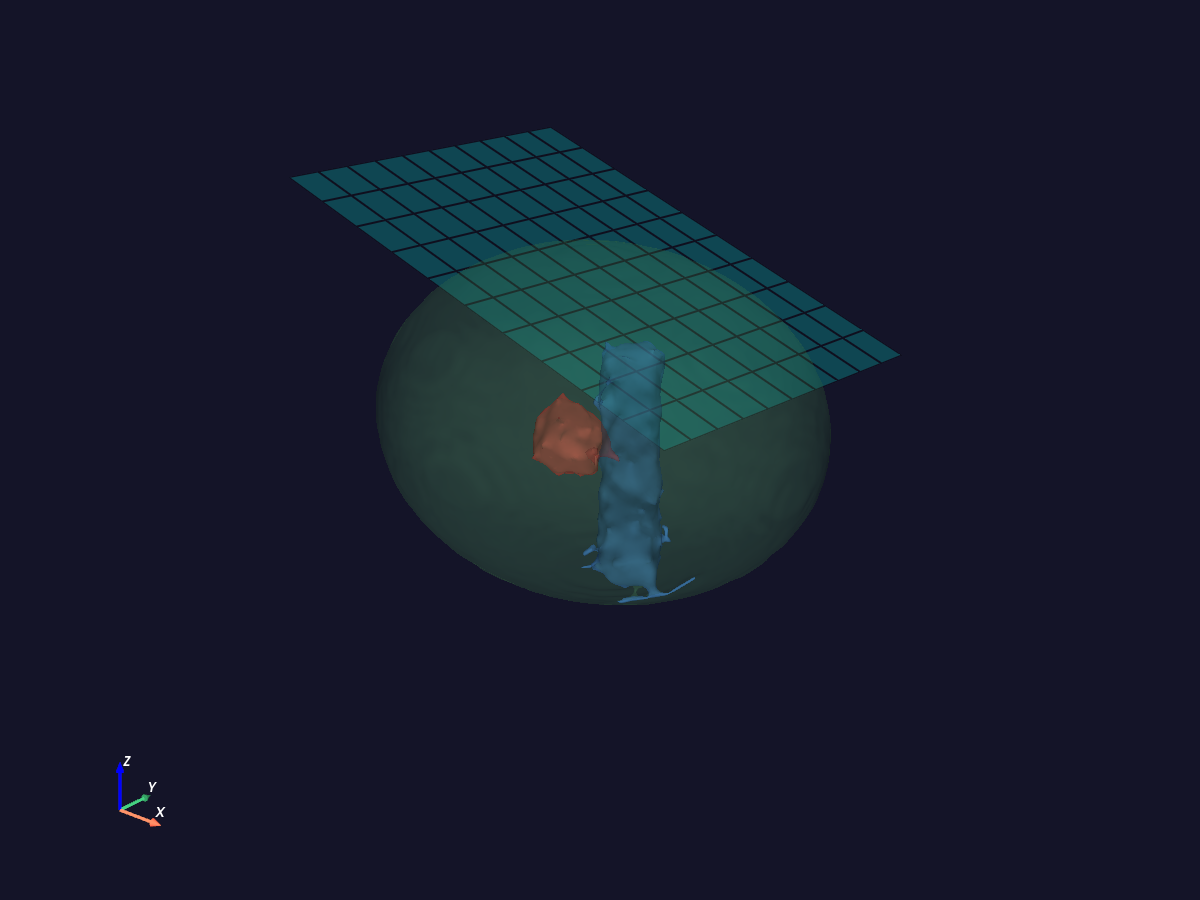

Saved: results/03_vtk_volume_rendering.png


In [3]:
"""
03_visualize_3d_vtk.py
----------------------
Visualisation 3D du volume échographique avec PyVista (VTK).
Affiche:
  - Le volume abdominal en volume rendering
  - Un plan de coupe cyan simulant la sonde US
  - Un repère 3D (axes)

Usage:
  pip install pyvista -q
  python src/03_visualize_3d_vtk.py
"""
import os
import numpy as np
!pip install pyvista -q
import pyvista as pv

DATA_DIR = "data"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)


def mask_to_mesh(mask, spacing=(1, 1, 1)):
    """Convertit un masque binaire 3D en surface (marching cubes) via VTK/PyVista."""
    grid = pv.ImageData()
    grid.dimensions = np.array(mask.shape) + 1  # +1: valeurs definies aux noeuds, pas aux cellules
    grid.spacing = spacing
    grid.origin = (0, 0, 0)
    grid.cell_data["mask"] = mask.flatten(order="F").astype(float)
    grid = grid.cells_to_points("mask")
    surface = grid.contour(isosurfaces=[0.5], scalars="mask")
    return surface.smooth(n_iter=30, relaxation_factor=0.1)


def main():
    print("Loading segmented masks (from 02_preprocess_segment.py)...")
    liver_mask = np.load(f"{DATA_DIR}/liver_mask.npy")
    vessel_mask = np.load(f"{DATA_DIR}/vessel_mask.npy")
    lesion_mask = np.load(f"{DATA_DIR}/lesion_mask.npy")

    plotter = pv.Plotter(off_screen=True, window_size=(1200, 900))
    plotter.set_background("#141428")

    # Foie: enveloppe translucide (contexte anatomique)
    liver_surf = mask_to_mesh(liver_mask)
    plotter.add_mesh(liver_surf, color="#5da87a", opacity=0.25, smooth_shading=True, name="liver")

    # Vaisseau: structure tubulaire, bien visible
    vessel_surf = mask_to_mesh(vessel_mask)
    plotter.add_mesh(vessel_surf, color="#3f7fd6", opacity=0.9, smooth_shading=True, name="vessel")

    # Lesion: nodule, couleur d'alerte
    lesion_surf = mask_to_mesh(lesion_mask)
    plotter.add_mesh(lesion_surf, color="#d64545", opacity=0.95, smooth_shading=True, name="lesion")

    # Plan de coupe simulant la sonde echographique (inchange)
    probe = pv.Plane(
        center=(64, 64, 100),
        direction=(0.3, 0.1, 1.0),
        i_size=90,
        j_size=70,
    )
    plotter.add_mesh(probe, color="cyan", opacity=0.25, show_edges=True, line_width=2, name="probe_plane")

    plotter.add_axes(line_width=3, color="white")

    # Camera: vraie vue 3/4, cadree sur le volume entier (0-128 dans chaque axe)
    plotter.camera_position = [
        (280, -180, 220),   # position (vue oblique, reculee pour cadrer tout le volume)
        (64, 64, 64),       # point focal: centre du volume
        (0, 0, 1),          # up vector
    ]
    plotter.camera.zoom(1.15)

    output_path = f"{RESULTS_DIR}/03_vtk_volume_rendering.png"
    plotter.show(screenshot=output_path)
    print(f"Saved: {output_path}")


if __name__ == "__main__":
    main()

AR Ultrasound Probe Simulation
  Saved: results/04_ar_frame_01.png
  Saved: results/04_ar_frame_02.png
  Saved: results/04_ar_frame_03.png
  Saved: results/04_ar_frame_04.png
Saved: results/04_ar_simulation_collage.png


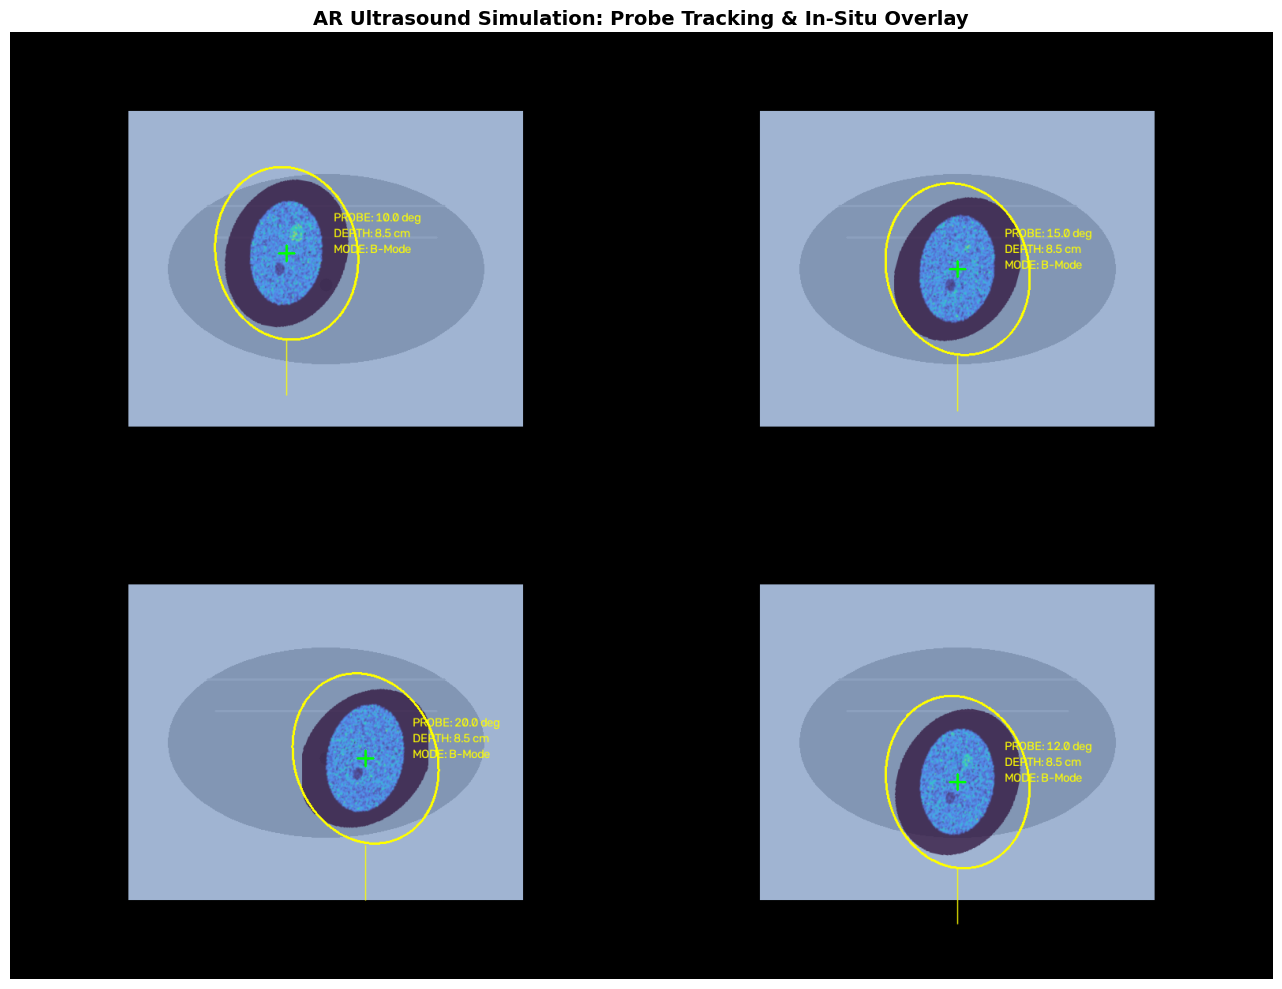

In [4]:
"""
04_ar_probe_simulation.py
---------------------------
Simulation d'un overlay AR pour guidage échographique.
Simule:
  1. Une caméra regardant un patient (image RGB)
  2. Un probe US virtuel dont la position est trackée
  3. La projection de l'image US 2D sur le patient (overlay AR)

C'est l'équivalent logiciel de ce que ferait un système AR avec:
  - Tracking du probe (optique ou EM)
  - Calibration caméra-probe
  - Rendu de la slice US dans le repère patient
"""
import os
import numpy as np
import cv2

DATA_DIR = "data"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

def create_patient_background(width=800, height=600):
    """
    Simule une image de caméra regardant un torse patient.
    En réalité, ce serait le flux vidéo d'une caméra AR (HoloLens, etc.).
    """
    bg = np.zeros((height, width, 3), dtype=np.uint8)
    # Peau
    bg[100:500, 150:650] = [210, 180, 160]
    # Ombres
    cv2.ellipse(bg, (400, 300), (200, 120), 0, 0, 360, (180, 150, 130), -1)
    # Marqueurs anatomiques (ombilic, côtes)
    cv2.circle(bg, (400, 320), 8, (160, 130, 110), -1)
    cv2.line(bg, (250, 220), (550, 220), (190, 160, 140), 2)
    cv2.line(bg, (260, 260), (540, 260), (190, 160, 140), 2)
    return bg

def get_us_slice_from_volume(volume, angle_deg=15, slice_z=64):
    """
    Extrait une slice 2D du volume 3D avec rotation.
    Simule l'acquisition d'une image US par le probe orienté.
    """
    h, w = volume.shape[0], volume.shape[1]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle_deg, 1.0)
    slice_2d = volume[:, :, slice_z]
    rotated = cv2.warpAffine(slice_2d, M, (w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=0)
    return rotated

def apply_us_colormap(slice_gray):
    """
    Applique une fausse couleur typique de l'échographie médicale
    (souvent du jaune-vert ou grayscale inversé selon les appareils).
    """
    slice_8bit = (slice_gray * 255).astype(np.uint8)
    # Colormap personnalisée: noir -> bleu -> cyan -> jaune -> blanc
    colored = cv2.applyColorMap(slice_8bit, cv2.COLORMAP_TURBO)
    return colored

def composite_ar_frame(patient_bg, us_image, probe_pos, probe_angle):
    """
    Compose l'image finale AR:
      - Fond: caméra patient
      - Overlay: image US projetée à la position du probe
      - HUD: informations cliniques (position, angle, profondeur)
    """
    frame = patient_bg.copy()
    h, w = frame.shape[:2]

    # Redimensionnement de l'image US pour qu'elle s'intègre au torse
    us_h, us_w = 200, 160
    us_resized = cv2.resize(us_image, (us_w, us_h))

    # Position du coin supérieur gauche de l'overlay
    x, y = probe_pos

    # Création d'un masque pour l'overlay (forme arrondie de sonde)
    mask = np.zeros((us_h, us_w), dtype=np.uint8)
    cv2.ellipse(mask, (us_w//2, us_h//2), (us_w//2 - 5, us_h//2 - 5),
                probe_angle, 0, 360, 255, -1)

    # Rotation de l'overlay selon l'angle du probe
    if probe_angle != 0:
        center = (us_w // 2, us_h // 2)
        M = cv2.getRotationMatrix2D(center, -probe_angle, 1.0)
        us_resized = cv2.warpAffine(us_resized, M, (us_w, us_h),
                                    borderMode=cv2.BORDER_CONSTANT, borderValue=(0,0,0))
        mask = cv2.warpAffine(mask, M, (us_w, us_h),
                              borderMode=cv2.BORDER_CONSTANT, borderValue=0)

    # Fusion avec le fond (alpha blending)
    x1, y1 = max(0, x - us_w//2), max(0, y - us_h//2)
    x2, y2 = min(w, x1 + us_w), min(h, y1 + us_h)

    # Ajustement si hors limites
    if x1 < 0 or y1 < 0 or x2 > w or y2 > h:
        return frame  # skip si hors cadre

    roi = frame[y1:y2, x1:x2]
    mask_3ch = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR) / 255.0

    # Blend: AR overlay semi-transparent
    blended = (roi * (1 - mask_3ch * 0.75) + us_resized * (mask_3ch * 0.75)).astype(np.uint8)
    frame[y1:y2, x1:x2] = blended

    # --- HUD (Head-Up Display) AR ---
    # Cadre autour du probe
    cv2.ellipse(frame, (x, y), (us_w//2 + 10, us_h//2 + 10),
                -probe_angle, 0, 360, (0, 255, 255), 2)

    # Ligne de pointillés vers la profondeur (simulation)
    cv2.line(frame, (x, y + us_h//2 + 10), (x, y + 180), (0, 255, 255), 1, cv2.LINE_AA)

    # Texte d'information
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(frame, f"PROBE: {probe_angle:.1f} deg", (x + 60, y - 40),
                font, 0.5, (0, 255, 255), 1, cv2.LINE_AA)
    cv2.putText(frame, f"DEPTH: 8.5 cm", (x + 60, y - 20),
                font, 0.5, (0, 255, 255), 1, cv2.LINE_AA)
    cv2.putText(frame, "MODE: B-Mode", (x + 60, y),
                font, 0.5, (0, 255, 255), 1, cv2.LINE_AA)

    # Croix centrale (crosshair)
    cv2.drawMarker(frame, (x, y), (0, 255, 0), cv2.MARKER_CROSS, 20, 2)

    return frame

def main():
    print("AR Ultrasound Probe Simulation")

    # Chargement du volume
    volume = np.load(f"{DATA_DIR}/phantom_us_3d.npy")

    # Création du fond patient
    patient_bg = create_patient_background(800, 600)

    # Paramètres de la simulation
    probe_positions = [(350, 280), (400, 300), (450, 320), (400, 350)]
    probe_angles = [10, 15, 20, 12]
    slice_indices = [60, 64, 68, 62]

    for i, (pos, angle, sidx) in enumerate(zip(probe_positions, probe_angles, slice_indices)):
        # Extraction de la slice US
        us_slice = get_us_slice_from_volume(volume, angle_deg=angle, slice_z=sidx)
        us_colored = apply_us_colormap(us_slice)

        # Composition AR
        frame = composite_ar_frame(patient_bg, us_colored, pos, angle)

        # Sauvegarde
        out_path = f"{RESULTS_DIR}/04_ar_frame_{i+1:02d}.png"
        cv2.imwrite(out_path, frame)
        print(f"  Saved: {out_path}")

    # Image finale: collage des 4 frames
    frames = [cv2.imread(f"{RESULTS_DIR}/04_ar_frame_{i+1:02d}.png") for i in range(4)]
    top = np.hstack(frames[:2])
    bottom = np.hstack(frames[2:])
    collage = np.vstack([top, bottom])
    collage_rgb = cv2.cvtColor(collage, cv2.COLOR_BGR2RGB)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(14, 10))
    plt.imshow(collage_rgb)
    plt.axis('off')
    plt.title("AR Ultrasound Simulation: Probe Tracking & In-Situ Overlay",
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/04_ar_simulation_collage.png", dpi=150, bbox_inches='tight')
    print(f"Saved: {RESULTS_DIR}/04_ar_simulation_collage.png")
    plt.show()

if __name__ == "__main__":
    main()